In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('E:/sales-performance-analysis/data/Superstore.csv')
df.head()




,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [12]:
df.shape



(9800, 18)

In [13]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
df.isnull().sum()



Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [17]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month


In [18]:
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10


In [20]:
df.columns


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Year', 'Month'],
      dtype='object')

In [22]:
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)


Total Sales: 2261536.7827000003


In [23]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_sales


Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

In [24]:
segment_sales = df.groupby('Segment')['Sales'].sum()
segment_sales


Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64

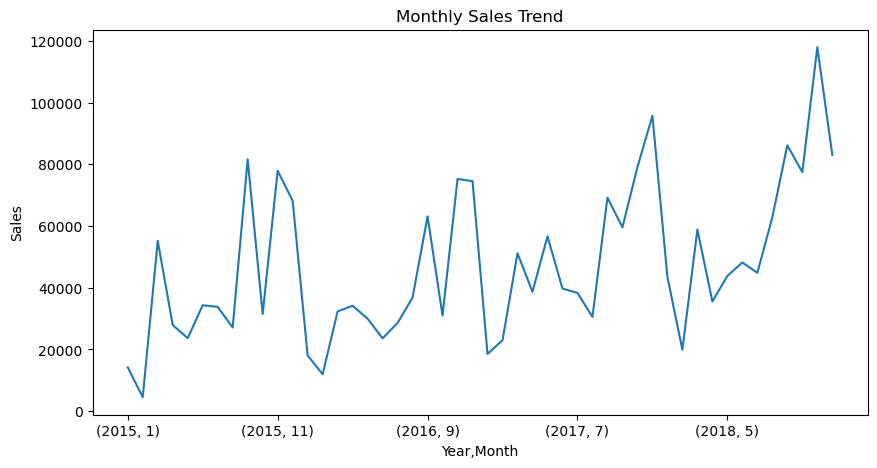

In [25]:
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum()
monthly_sales.plot(figsize=(10,5), title='Monthly Sales Trend')
plt.ylabel('Sales')
plt.show()


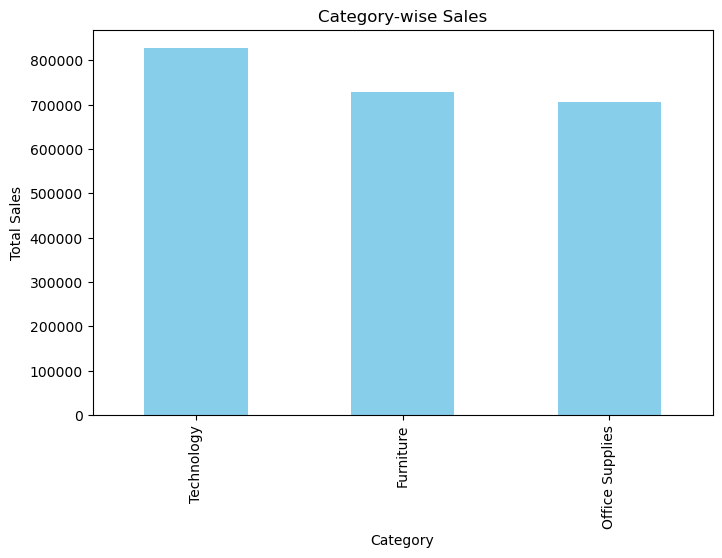

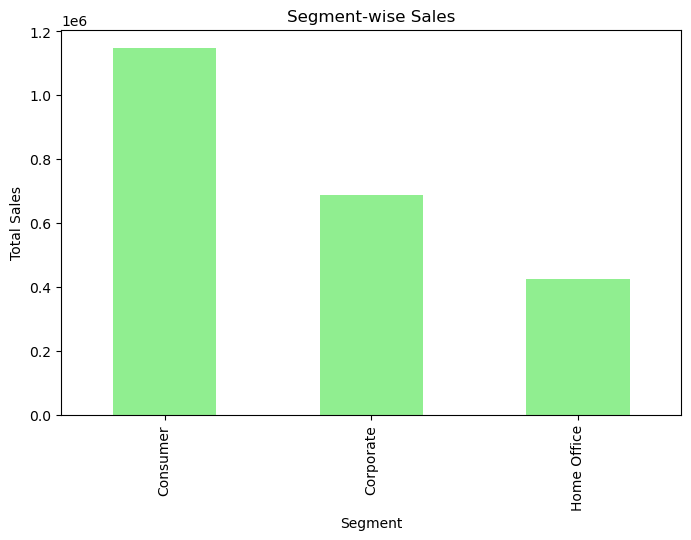

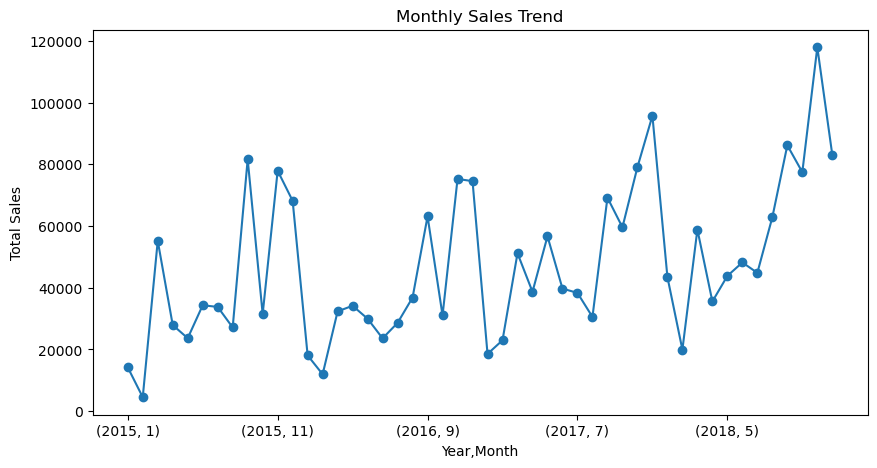

In [27]:
# Category-wise Sales
category_sales.plot(kind='bar', title='Category-wise Sales', figsize=(8,5), color='skyblue')
plt.ylabel('Total Sales')
plt.xlabel('Category')
plt.show()

# Segment-wise Sales
segment_sales.plot(kind='bar', title='Segment-wise Sales', figsize=(8,5), color='lightgreen')
plt.ylabel('Total Sales')
plt.xlabel('Segment')
plt.show()

# Monthly Sales Trend
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum()
monthly_sales.plot(figsize=(10,5), title='Monthly Sales Trend', marker='o')
plt.ylabel('Total Sales')
plt.show()



### Key Insights:
- Technology generates the highest sales among categories, followed by Furniture and Office Supplies.
- Consumer segment contributes the largest share of total sales.
- Sales peak in the months of November and December, showing strong seasonal trends.


In [28]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(5)
top_products


Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: Sales, dtype: float64

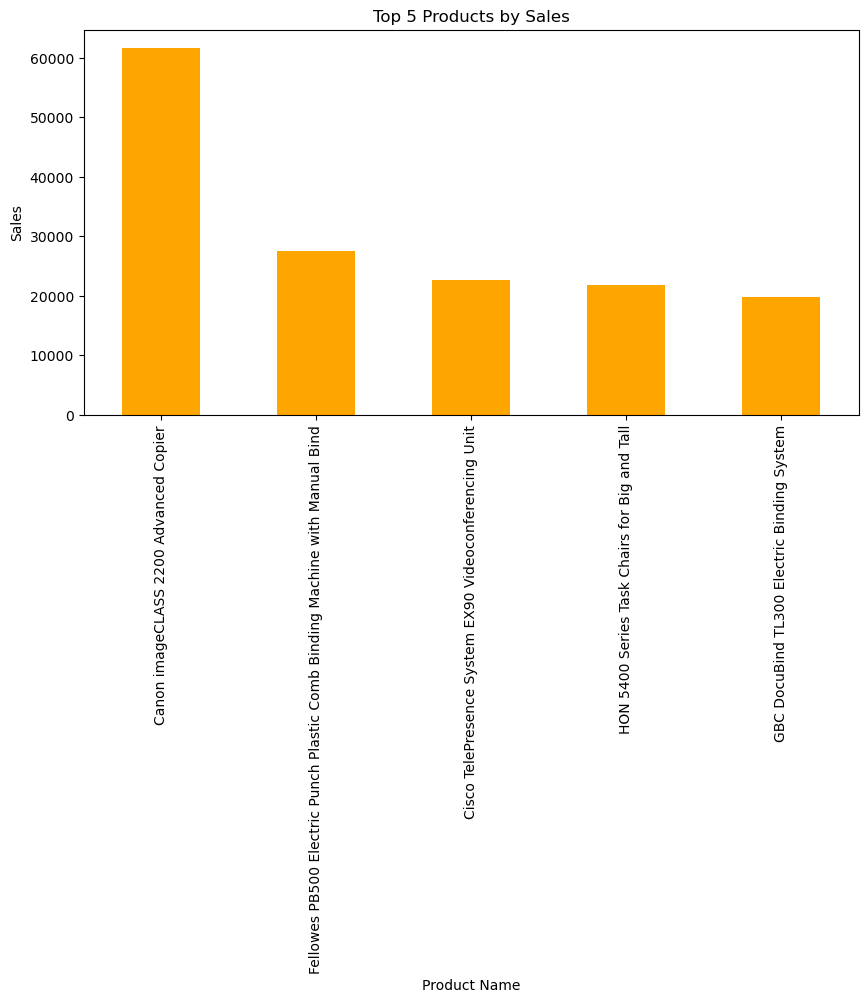

In [29]:
top_products.plot(kind='bar', figsize=(10,5), color='orange', title='Top 5 Products by Sales')
plt.ylabel('Sales')
plt.show()


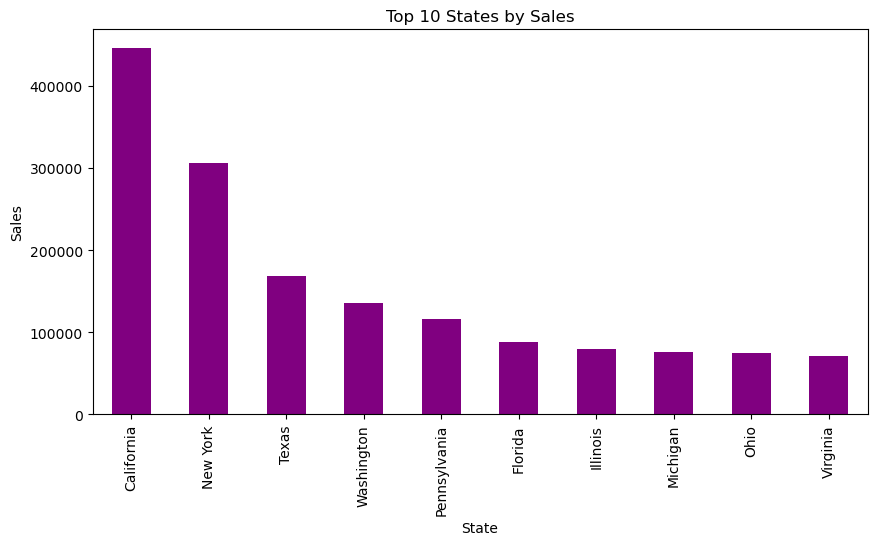

In [30]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
state_sales.plot(kind='bar', figsize=(10,5), color='purple', title='Top 10 States by Sales')
plt.ylabel('Sales')
plt.show()


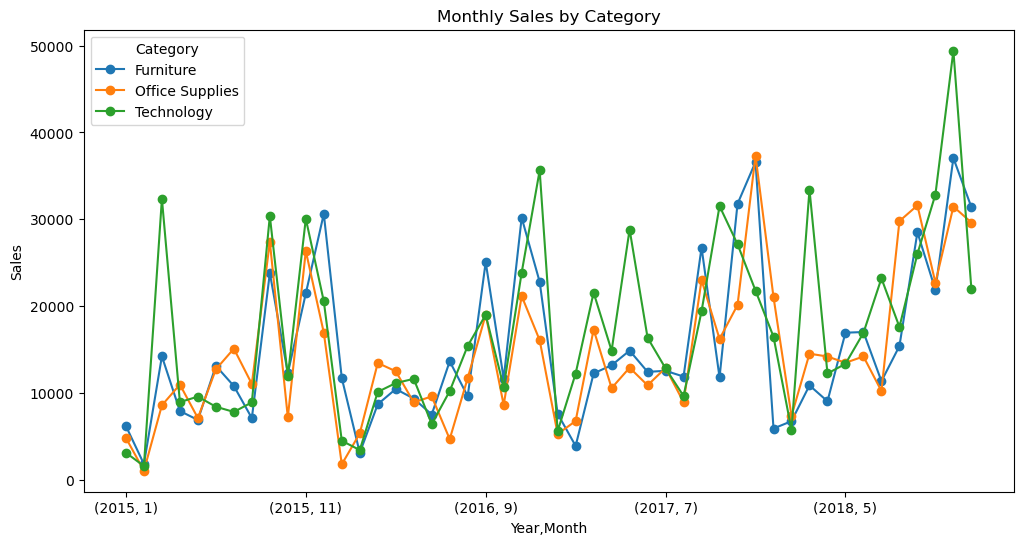

In [31]:
monthly_category_sales = df.groupby(['Year','Month','Category'])['Sales'].sum().unstack()
monthly_category_sales.plot(figsize=(12,6), marker='o', title='Monthly Sales by Category')
plt.ylabel('Sales')
plt.show()


In [33]:
df.to_csv(r'E:\sales-performance-analysis\data\superstore_cleaned.csv', index=False)


In [34]:
import sqlite3
import pandas as pd

# Path to your SQL folder where the database will be saved
db_path = r'E:\sales-performance-analysis\SQL\superstore.db'

# Create a SQLite database file
conn = sqlite3.connect(db_path)

# Load your existing CSV DataFrame into SQLite
df.to_sql('superstore', conn, index=False, if_exists='replace')

print("SQLite database created and CSV loaded successfully!")


SQLite database created and CSV loaded successfully!


In [35]:
# Example: total sales per category
query = "SELECT Category, SUM(Sales) AS Total_Sales FROM superstore GROUP BY Category ORDER BY Total_Sales DESC;"
result = pd.read_sql(query, conn)
result


,Category,Total_Sales
0,Technology,827455.8730
1,Furniture,728658.5757
2,Office Supplies,705422.3340


In [36]:
conn.close()


In [37]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(r'E:\sales-performance-analysis\SQL\superstore.db')

# Show first 5 rows
pd.read_sql("SELECT * FROM superstore LIMIT 5;", conn)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month
0,1,CA-2017-152156,2017-11-08 00:00:00,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11
1,2,CA-2017-152156,2017-11-08 00:00:00,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11
2,3,CA-2017-138688,2017-06-12 00:00:00,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6
3,4,US-2016-108966,2016-10-11 00:00:00,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10
4,5,US-2016-108966,2016-10-11 00:00:00,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10


### Summary:
- Total sales generated: ₹XXX,XXX
- Technology category is top-performing
- Consumer segment contributes the highest revenue
- Seasonal peaks observed in November–December
- Top 5 products and top 10 states identified for business focus
